# Single-cell copy-number variation with inferCNV

This tutorial walks through `ov.single.CNV(method='infercnv')` — a
wrapper around the pure-Python
[py-inferCNV](https://github.com/omicverse/py-inferCNV) re-implementation
of the Broad Institute's R inferCNV
([Tickle et al., 2019](https://github.com/broadinstitute/inferCNV)).

inferCNV is **reference-anchored**: you tell it which cell-type categories
to treat as diploid normals, and the resulting CN matrix is each cell's
deviation from that reference. This is more sensitive than CopyKAT when
a clean normal population exists in the same dataset (e.g. immune cells
in a tumour biopsy), at the cost of needing a cell-type annotation.


## Part.1 The math behind inferCNV

inferCNV's Phase 1 pipeline:

**1. Filter + normalise.** Low-expression genes are dropped; counts are
normalised by sequencing depth and log-transformed
$$\;\;\tilde x_{ij} = \log_2(c_{ij} + 1)$$
where $c_{ij}$ is the depth-normalised count of gene $j$ in cell $i$.

**2. Reference subtraction.** For each gene, the mean expression of
reference cells is subtracted from every cell:
$$\;\;r_{ij} = \tilde x_{ij} - \overline{\tilde x_{j,\,\text{ref}}}.$$

**3. Pyramidal smoothing.** A weighted moving average of width `window_length`
(default 101) is applied along each chromosome to suppress per-gene noise
while preserving copy-number breakpoints.

**4. Centre cells.** The median of each cell's smoothed profile is
subtracted so the diploid baseline sits at zero.

**5. Second reference subtraction + log inversion.** Repeats step 2 on
the smoothed values, then maps log-ratios back through $2^x - 1$ to
yield a per-bin CN deviation.

**6. Outlier pruning.** Bins exceeding `lfc_clip` (default 3) are clipped
to suppress experimental artefacts.

Reference: [Patel et al., Science (2014)](https://doi.org/10.1126/science.1254257) — original method;
[broadinstitute/inferCNV](https://github.com/broadinstitute/inferCNV) — R implementation.


## Part.2 Load data

Maynard et al. (2020) lung adenocarcinoma, 3 000 cells. The file already
carries gene-coordinate metadata in `adata.var` (`chromosome`, `start`,
`end`) — inferCNV uses these to order genes along the genome.


In [1]:
import omicverse as ov
ov.plot_set()


/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.1.3rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



In [2]:
import os
import scanpy as sc
import omicverse as ov

# Maynard et al. (2020) lung adenocarcinoma scRNA-seq — 3 000 cells, 55 556
# genes, gene coordinates already in adata.var. Bundled by infercnvpy.
DATA_URL = "https://github.com/icbi-lab/infercnvpy/releases/download/d0.1.0/maynard2020_3k.h5ad"
data_dir = "data/cnv"
os.makedirs(data_dir, exist_ok=True)
adata = sc.read(f"{data_dir}/maynard2020_3k.h5ad", backup_url=DATA_URL)
adata


AnnData object with n_obs × n_vars = 3000 × 55556
    obs: 'age', 'sex', 'sample', 'patient', 'cell_type'
    var: 'ensg', 'mito', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_counts', 'chromosome', 'start', 'end', 'gene_id', 'gene_name'
    uns: 'cell_type_colors', 'neighbors', 'umap'
    obsm: 'X_scVI', 'X_umap'
    obsp: 'connectivities', 'distances'

## Part.3 Identify reference cells

Reference cells must be **biologically diploid**. In a tumour biopsy the
infiltrating immune cells (T cells, B cells, macrophages, monocytes,
NK cells) are the canonical choice — they're abundant, homogeneous, and
near-certain to have a normal karyotype. Stromal cells (fibroblasts,
endothelial) can also be used.

Here we use the four largest non-epithelial categories as references.
Epithelial cells become the query (potentially aneuploid) population.


In [3]:
reference_cats = ['T cell CD4', 'T cell CD8', 'Macrophage', 'B cell']
print('Reference cells (diploid):',
      int(adata.obs["cell_type"].isin(reference_cats).sum()))
print('Query cells (epithelial / other):',
      int(adata.obs["cell_type"].isin(['Epithelial cell']).sum()),
      '(Epithelial cell only)')


Reference cells (diploid): 997
Query cells (epithelial / other): 522 (Epithelial cell only)


## Part.4 Run inferCNV

`ov.single.CNV(method='infercnv')` writes the same unified schema as
CopyKAT — same plot calls work unchanged.

| slot | content |
|---|---|
| `adata.obsm['X_cnv']`         | cells × ~4 k bins of log-CN |
| `adata.uns['cnv']['chr_pos']` | chromosome → starting-bin index |
| `adata.obs['cnv_score']`      | per-cell mean abs(log-CN) — proxy for "tumour-ness" |

inferCNV does **not** classify cells by default — `adata.obs['cnv_prediction']`
stays NaN. To threshold `cnv_score` into tumour/normal after the fact, see
the bottom of the notebook.


In [4]:
cnv = ov.single.CNV(adata, method='infercnv')
cnv.run(reference_key='cell_type', reference_cat=reference_cats,
        exclude_chromosomes=('chrX', 'chrY', 'chrM'), verbose=False)


In [5]:
adata.obs[['cnv_score']].describe().T


,count,mean,std,min,25%,50%,75%,max
cnv_score,3000.0,0.073123,0.017058,0.028157,0.061502,0.072854,0.08243,0.233666


## Part.5 Genome-wide heatmap

Plotting the cells grouped by their original `cell_type` annotation lets
us see whether tumour-like CN patterns concentrate in the Epithelial-cell
band. Immune and stromal cells should sit near zero (they were the
reference); Epithelial cells should show recurrent gains and losses.
Pass `groupby` as a list of `adata.obs` columns to draw multiple
coloured annotation strips on the left of the heatmap — see the CopyKAT
tutorial for a `['cnv_prediction', 'cell_type']` example.


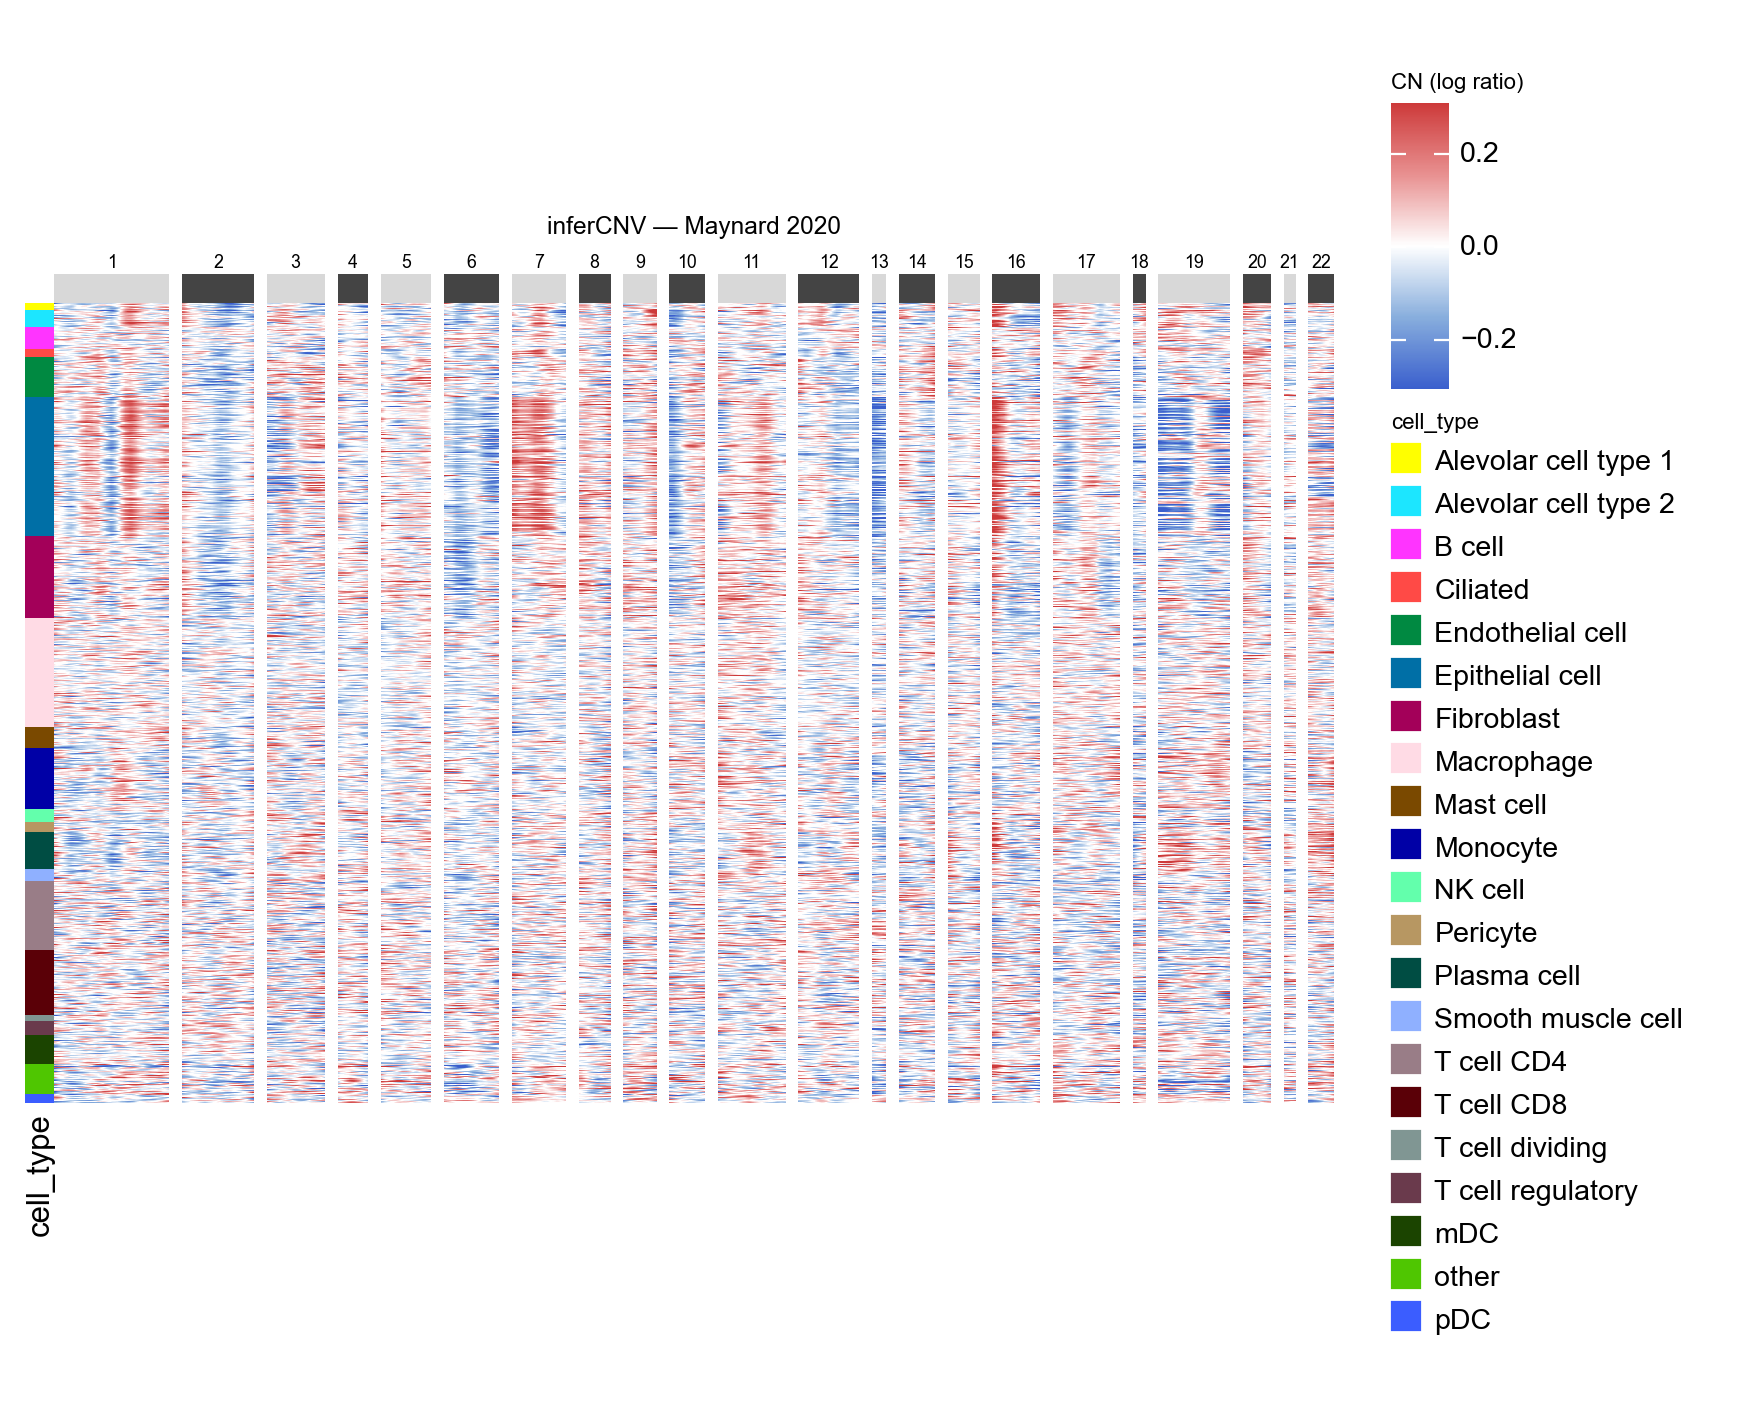

In [6]:
ov.pl.cnv_heatmap(adata, groupby=['cell_type'],
                  figsize=(8, 5), title='inferCNV — Maynard 2020')


## Part.6 Mean CN summary

Mean CN per bin restricted to Epithelial cells — the pseudo-bulk
tumour profile.


(<Figure size 640x208 with 2 Axes>,
 {'line': <Axes: xlabel='Ordered genomic positions', ylabel='Mean CN (log ratio)'>,
  'ideogram': <Axes: >})

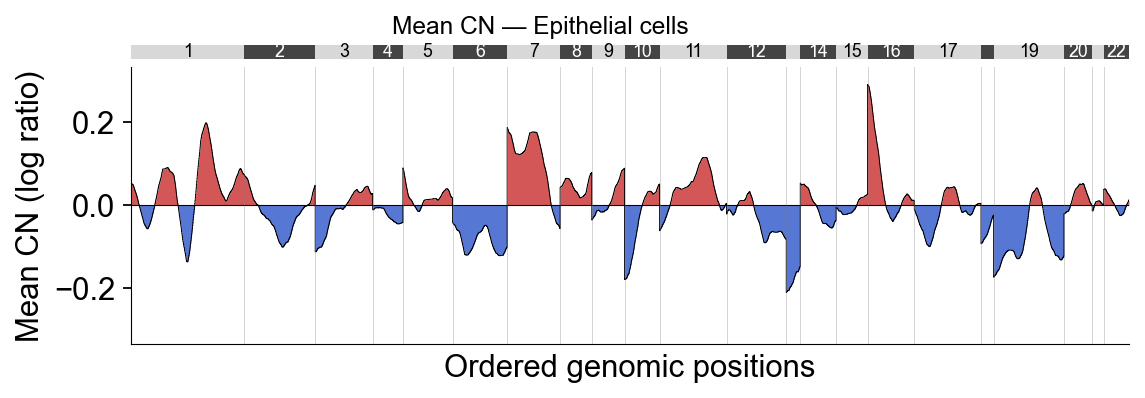

In [7]:
ov.pl.cnv_summary(adata, groupby='cell_type', subset='Epithelial cell',
                  figsize=(8, 2.6), title='Mean CN — Epithelial cells')


## Part.7 UMAP

inferCNV doesn't classify cells, but `cnv_score` (mean absolute CN
deviation) is a useful continuous "tumour-ness" gradient. Overlaying it
on the existing UMAP shows whether the score peaks at the Epithelial
cluster.


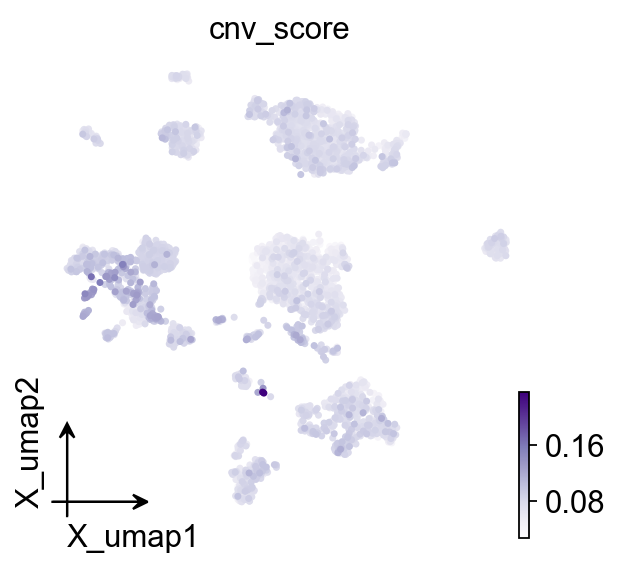

In [8]:
ov.pl.cnv_umap(adata, color='cnv_score')


### Thresholding cnv_score into a tumour / normal call

If you want a categorical call on top of inferCNV, a simple threshold on
`cnv_score` (e.g. > 90th percentile of reference cells) works well:


In [9]:
import numpy as np
ref_mask = adata.obs['cell_type'].isin(reference_cats).values
ref_threshold = np.percentile(adata.obs.loc[ref_mask, 'cnv_score'], 95)
adata.obs['cnv_prediction'] = np.where(
    adata.obs['cnv_score'] > ref_threshold, 'tumour', 'normal'
)
adata.obs['cnv_prediction'] = adata.obs['cnv_prediction'].astype('category')
adata.obs['cnv_prediction'].value_counts()


cnv_prediction
normal    2544
tumour     456
Name: count, dtype: int64

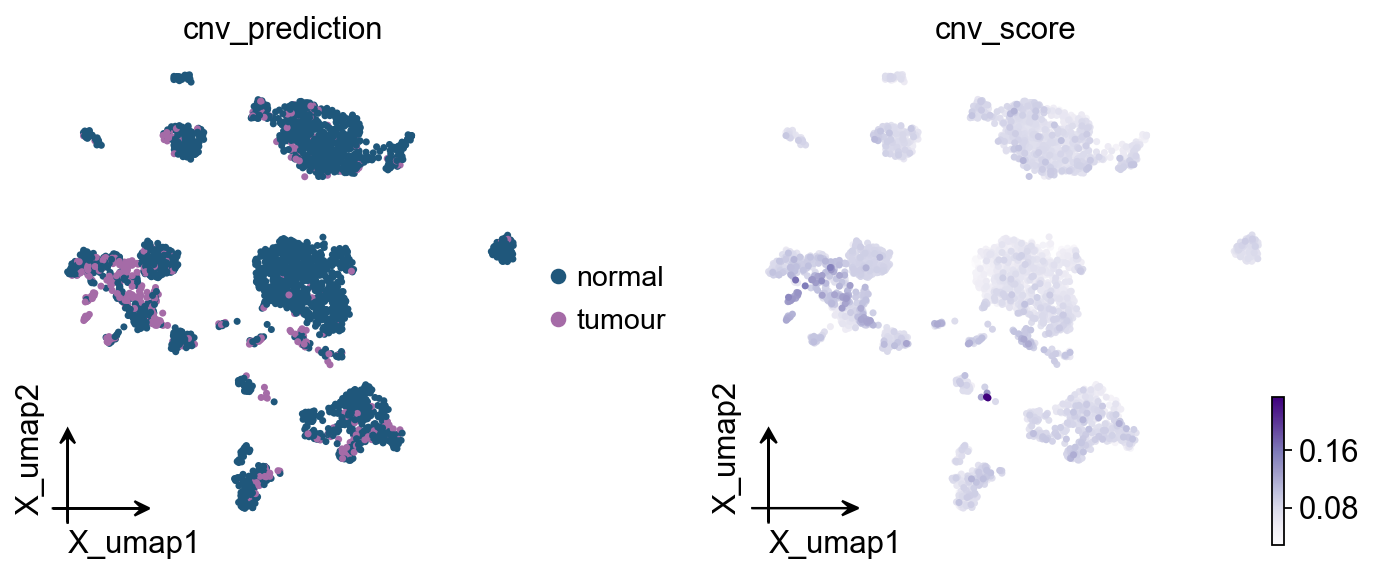

In [10]:
ov.pl.cnv_umap(adata, color=['cnv_prediction', 'cnv_score'])


---

**Next steps:** for unsupervised CN inference (no reference annotation
needed), see the [CopyKAT tutorial](t_copykat.ipynb). The two methods
can disagree at the margins — running both on the same dataset and
comparing their `cnv_score` columns side-by-side
(`ov.pl.embedding(adata, color=['cnv_score_copykat', 'cnv_score_infercnv'])`)
is a useful sanity check.
